Downsampling the UiS4ADL dataset from 100hz to 32hz to match the sampling frequency of the PAAL ADL dataset.

In [1]:
import os
import warnings
import json

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import welch
import matplotlib.pyplot as plt

# Suppress warnings from Python and external libraries
os.environ["PYTHONWARNINGS"] = "ignore"  # Suppress Python warnings
warnings.filterwarnings("ignore")

In [2]:
with open('../Data/adl_dict.json', 'r') as f:
    adl_dict = json.load(f)

In [3]:
initial_fs = 100 # sampling frequency in Hz
path = r"../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv"

target_fs = 32 # target sampling frequency in Hz

In [4]:
df = pd.read_csv(path)

## Drop columns

Since PAAL ADL has only 3 acceleration channels, the gyroscope and the remaining channels will be removed from the UiS4ADL dataset for consistency.

In [5]:
metadata_cols = ['adl', 'session', 'subject', 'fileID']
sensor_cols = ['accX[mg]', 'accY[mg]', 'accZ[mg]']

## Downsample the UiS4ADL dataset

Linear interpolation was used as a resampling method.

In [6]:
def resample_file(df_file, target_hz=32):
    t_orig = df_file['timestamp'].values / 1000.0 # timestamp in seconds
    
    duration = t_orig[-1]
    t_new = np.arange(0, duration, 1 / target_hz)

    out = {'timestamp': t_new * 1000.0}  # timestamp in milliseconds

    # Resample sensor data using interpolation
    for col in sensor_cols:
        f = interp1d(t_orig, df_file[col].values, kind='linear')
        out[col] = f(t_new)

    df_out = pd.DataFrame(out)

    # Attach metadata
    for col in metadata_cols:
        df_out[col] = df_file[col].iloc[0]

    return df_out

In [7]:
df_32hz = (
    df.groupby('fileID')
      .apply(resample_file)
      .reset_index(drop=True)
)

In [8]:
df_32hz

,timestamp,accX[mg],accY[mg],accZ[mg],adl,session,subject,fileID
0,0.00,-198.000,-348.000,878.000,1,1,0,70
1,31.25,-219.125,-375.500,785.500,1,1,0,70
2,62.50,-193.750,-450.250,767.750,1,1,0,70
3,93.75,-150.625,-539.500,785.875,1,1,0,70
4,125.00,-133.500,-522.000,795.000,1,1,0,70
...,...,...,...,...,...,...,...,...
2696620,23343.75,933.750,-329.000,-649.000,9,5,3245,4947
2696621,23375.00,1161.000,-326.000,-262.000,9,5,3245,4947
2696622,23406.25,1234.375,4.125,-341.875,9,5,3245,4947
2696623,23437.50,1121.750,139.500,-360.500,9,5,3245,4947


### Sanity checks

In [9]:
# Check whether the sampling grid is regular after resampling
expected = 1000.0 / float(target_fs)  # in miliseconds
tol_ms=1e-12
irregular_timestamps_files = []
for fid, g in df_32hz.groupby('fileID'):
    ts = g['timestamp'].values
    dt = np.diff(ts)
    max_err = np.max(np.abs(dt - expected))
    if max_err > tol_ms:
        irregular_timestamps_files.append((fid, max_err, np.unique(dt)))
if not irregular_timestamps_files:
    print(f"All files have a regular sampling grid (expected {expected:.3f} ms, tol {tol_ms} ms).")
else:
    print(f"Files with irregular timestamps were detected (expected {expected:.3f} ms, tol {tol_ms} ms):")
    for fid, max_err, uniques in irregular_timestamps_files:
        print(f"fileID {fid}: max err = {max_err:.6f} ms, unique dt ≈ {uniques}")

All files have a regular sampling grid (expected 31.250 ms, tol 1e-12 ms).


In [10]:
# Check metadata integrity, 'adl', 'session' and 'subject' should not vary within a file
errors = []
for col in metadata_cols:
    if col == 'fileID':
        continue
    max_unique = df_32hz.groupby('fileID')[col].nunique().max()
    if max_unique != 1:
        errors.append((col, max_unique))

if errors:
    for col, max_u in errors:
        print(f"Error: '{col}' varies within a file (max unique per fileID = {max_u})")
else:
    print("All files have consistent labels.")

All files have consistent labels.


In [11]:
# Compare signal energy via variation ratio to detect whether resampling introduces significant signal attenuation or energy loss
LOW_WARN = 0.70 # to 30% energy loss
HIGH_WARN = 1.30 # up to 30% energy gain

results = []
file_ids = df['fileID'].unique()

for fid in file_ids:
    df_o = df[df['fileID'] == fid]
    df_n = df_32hz[df_32hz['fileID'] == fid]
    warnings = []
    
    # Get metadata
    adl = df_o['adl'].iloc[0]
    adl_name = adl_dict.get(str(adl), adl_dict.get(adl, str(adl)))
    subject = df_o['subject'].iloc[0]
    session = df_o['session'].iloc[0]

    for col in sensor_cols:
        x_orig = df_o[col].values
        x_new  = df_n[col].values
        
        var_orig = np.var(x_orig)
        var_new  = np.var(x_new)
        
        if var_orig == 0:
            ratio = 1.0 if var_new == 0 else np.inf
        else:
            ratio = var_new / var_orig

        results.append({
            'fileID': fid,
            'adl': adl,
            'adl_name': adl_name,
            'subject': subject,
            'session': session,
            'column': col,
            'var_original': var_orig,
            'var_resampled': var_new,
            'ratio': ratio
        })
        
        if ratio < LOW_WARN or ratio > HIGH_WARN:
            warnings.append((col, var_orig, var_new, ratio))
    
    if warnings:
        print(f"\nResampling warnings for fileID: {fid} (adl: {adl_name} ({adl}), subject: {subject}, session: {session})")
        for col, var_orig, var_new, ratio in warnings:
            print(
                f"  {col:20s} | "
                f"var orig: {var_orig:10.6f} | "
                f"var new: {var_new:10.6f} | "
                f"ratio: {ratio:.3f}"
            )


Resampling warnings for fileID: 256 (adl: take off shoe (10), subject: 1505, session: 2)
  accY[mg]             | var orig: 96717.122760 | var new: 60026.767298 | ratio: 0.621

Resampling warnings for fileID: 301 (adl: take off shoe (10), subject: 2136, session: 2)
  accY[mg]             | var orig: 567818.590659 | var new: 393875.547251 | ratio: 0.694

Resampling warnings for fileID: 488 (adl: take off glasses (12), subject: 1358, session: 2)
  accY[mg]             | var orig: 505699.392438 | var new: 325068.016665 | ratio: 0.643

Resampling warnings for fileID: 669 (adl: sit down (13), subject: 1505, session: 3)
  accZ[mg]             | var orig: 48810.658303 | var new: 25228.181267 | ratio: 0.517

Resampling warnings for fileID: 770 (adl: stand up (14), subject: 1279, session: 1)
  accX[mg]             | var orig: 23312.409105 | var new: 31646.925754 | ratio: 1.358

Resampling warnings for fileID: 904 (adl: stand up (14), subject: 2160, session: 1)
  accY[mg]             | var orig

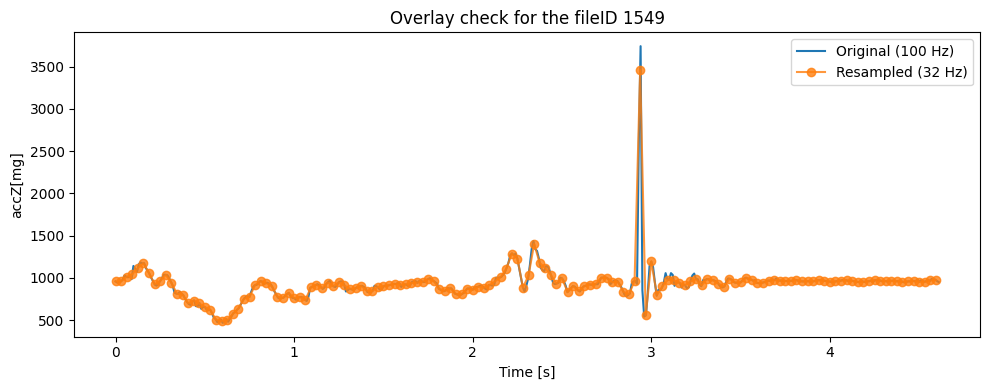

In [12]:
# Time-domain overlay plots of original vs resampled to visually confirm that resampling preserves the shape/amplitude
file_id = 1549
col = 'accZ[mg]'  # or whatever your signal column is called
t_max = 10.0  # seconds
dfo = df[df.fileID == file_id]
dfr = df_32hz[df_32hz.fileID == file_id]
to = dfo['timestamp'].values / 1000.0
tr = dfr['timestamp'].values / 1000.0
mask_o = to <= t_max
mask_r = tr <= t_max
plt.figure(figsize=(10, 4))
plt.plot(to[mask_o], dfo[col].values[mask_o], label='Original (100 Hz)')
plt.plot(tr[mask_r], dfr[col].values[mask_r], 'o-', label='Resampled (32 Hz)', alpha=0.8)
plt.xlabel('Time [s]')
plt.ylabel(col)
plt.legend()
plt.title(f'Overlay check for the fileID {file_id}')
plt.tight_layout()
plt.show()

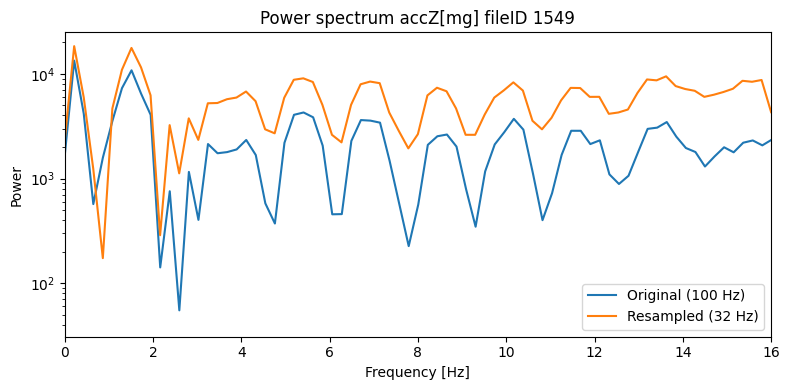

In [13]:
# Power spectral density comparison of original vs resampled (up to 16 Hz) to ensure that resampling does not introduce artifacts or lose important frequencies
file_id = 1549
col = 'accZ[mg]'
dfo = df[df.fileID == file_id]
dfr = df_32hz[df_32hz.fileID == file_id]
xo = dfo[col].values
xr = dfr[col].values
fo, po = welch(xo, fs=initial_fs, nperseg=2048)
fr, pr = welch(xr, fs=target_fs, nperseg=512)
plt.figure(figsize=(8, 4))
plt.semilogy(fo, po, label='Original (100 Hz)')
plt.semilogy(fr, pr, label='Resampled (32 Hz)')
plt.xlim(0, 16)   # Nyquist frequency (half of the sampling rate)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.legend()
plt.title(f'Power spectrum {col} fileID {file_id}')
plt.tight_layout()
plt.show()

## Save the downsampled dataset

In [15]:
 # Save the combined DataFrame to a new CSV file
output_file = f"../Data/UiS4ADL/Processed/UiS4ADL_acc_{target_fs}hz.csv"

# Remove the file if it already exists
if os.path.exists(output_file):
    os.remove(output_file)
    print(f"{output_file} has been removed successfully.")
else:
    print(f"{output_file} does not exist.")
    
# Save the combined DataFrame to a CSV file
df_32hz.to_csv(output_file, index=False)
print(f"The dataset was saved to {output_file}")

../Data/UiS4ADL/Processed/UiS4ADL_acc_32hz.csv does not exist.
The dataset was saved to ../Data/UiS4ADL/Processed/UiS4ADL_acc_32hz.csv
